# Lab: Linear Regression

## 1. Installation and Importing of Packages

### Installation

We install the required Python packages: numpy, pandas, matplotlib, statsmodels, and ISLP. The ISLP package contains the data sets and helper functions used throughout this lab. The !pip install command runs in the system shell and will download and install any missing packages.

In [7]:
!pip install numpy pandas matplotlib statsmodels ISLP

### Importing

Now we import all the libraries we'll need. We import numpy, pandas, and matplotlib for basic data handling and plotting. From statsmodels we import the core API for regression. We also import specific tools: variance_inflation_factor for multicollinearity diagnostics and anova_lm for analysis of variance. Finally, we import the ISLP package's data loader (load_data) and its model specification tools (ModelSpec, summarize, and poly). This sets up our environment for the lab.

In [8]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import ModelSpec as MS , summarize, poly

## 2. Simple Linear Regression

### Loading Boston data

We load the Boston housing data set using load_data("Boston"). This data set contains 506 observations and 13 variables, including the target variable medv (median house value). We display the column names to see which predictors are available.

In [9]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

### Creating the model matrix by hand

For a simple linear regression with one predictor (lstat), we can manually construct the design matrix X. We create a DataFrame with an intercept column (all ones) and a column for lstat. This is a good illustration of the underlying matrix structure. We then display the first four rows.

In [10]:
X = pd.DataFrame ({'intercept': np.ones(Boston.shape [0]) , 'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


### Extracting the response, and fit the model.

We extract the response variable medv as y. Then we use sm.OLS(y, X) to specify the ordinary least squares model, and call .fit() to estimate the coefficients. The results object contains all fitted parameters, residuals, and diagnostic information.

In [11]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

### Showing the table of the parameter estimates, their standard errors, t-statistics and p-values.

We use the summarize() function from ISLP to produce a clean table of coefficient estimates, standard errors, t-statistics, and p-values. This gives a quick overview of the significance of each predictor.

In [12]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


### Using Transformations: Fit and Transform

Instead of manually building the design matrix, we'll use a more flexible approach: ModelSpec. This object allows us to specify the model formula (e.g., ['lstat']) and then fit and transform the data. First we create a design object, fit it to the data (which checks variable existence and may pre‑compute transformations), and then transform to produce the model matrix. We display the first four rows to verify the structure.

In [13]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


### Using fit_transform

The two steps fit and transform can be combined into a single fit_transform call, which is more concise. We create the design object and immediately produce the model matrix X. This pattern will be used repeatedly for more complex models.

In [14]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


### Summary of OLS results

We can also view a full summary of the regression results using the summary() method of the fitted model. This includes many additional statistics like R‑squared, F‑statistic, and diagnostic tests. We won't display the full output here, but it's available if needed.

In [15]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           5.08e-88
Time:                        12:29:52   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Extracting parameters
The fitted coefficients are stored in the params attribute of the results object. We extract them to see the intercept and slope for lstat.

In [16]:
results.params

,0
intercept,34.553841
lstat,-0.950049


### Predictions for new data

To make predictions for new observations, we create a new DataFrame with the predictor values of interest (here lstat = 5, 10, 15). We then transform it using the same design object to create the corresponding model matrix. This ensures the same encoding (e.g., intercept) is applied.

In [17]:
new_df = pd.DataFrame ({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


### Predicted means

Using the get_prediction() method on the results object, we compute predictions for the new data. The predicted_mean attribute gives the point estimates.

In [18]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

### Confidence intervals

Confidence intervals for the mean response can be obtained by calling conf_int() with obs=False (the default). Here we produce 95% confidence intervals for the fitted values at lstat = 5, 10, 15.

In [19]:
new_predictions.conf_int(alpha =0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

### Prediction intervals

Prediction intervals for new individual observations are computed by setting obs=True. These intervals are wider than confidence intervals because they account for the additional variability of individual responses.

In [20]:
new_predictions.conf_int(obs=True , alpha =0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

### Define abline function

We define a helper function abline() to add a regression line to a plot. This function takes an axis object, intercept b, slope m, and optional plotting arguments, and draws the line across the current x‑axis limits.

In [21]:
def abline(ax , b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim ()
    ylim = [m * xlim [0] + b, m * xlim [1] + b]
    ax.plot(xlim , ylim)

### Redefine abline with more flexibility

We improve the abline function by allowing arbitrary positional (*args) and keyword (**kwargs) arguments to be passed to the underlying ax.plot() call. This makes the function more flexible (e.g., we can specify line color, style, width, etc.).

In [22]:
def abline(ax , b, m, *args , ** kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim ()
    ylim = [m * xlim [0] + b, m * xlim [1] + b]
    ax.plot(xlim , ylim , *args , ** kwargs)

### Plot scatter with regression line

We create a scatter plot of medv versus lstat using the DataFrame's plot.scatter() method. Then we add the fitted regression line using our abline function, passing the intercept and slope from the results, and specifying a red dashed line with width 3.

/tmp/ipykernel_1195/1142215236.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params [0],
/tmp/ipykernel_1195/1142215236.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params [1],


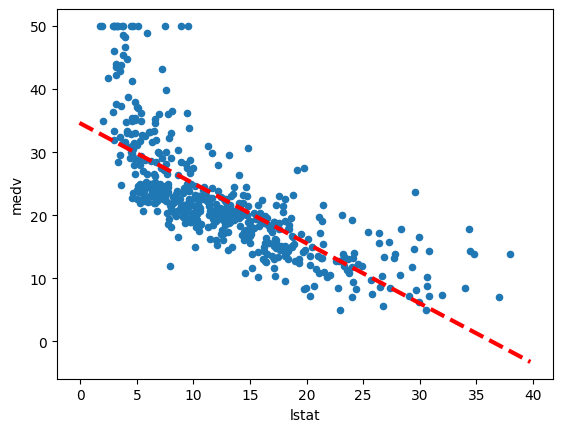

In [23]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax ,
    results.params [0],
    results.params [1],
    'r--',
    linewidth =3)

### Residual plot

Diagnostic plots help assess model assumptions. We create a residual plot: fitted values on the x‑axis and residuals on the y‑axis. We add a horizontal reference line at 0 using ax.axhline(). This plot can reveal non‑linearity or heteroscedasticity.

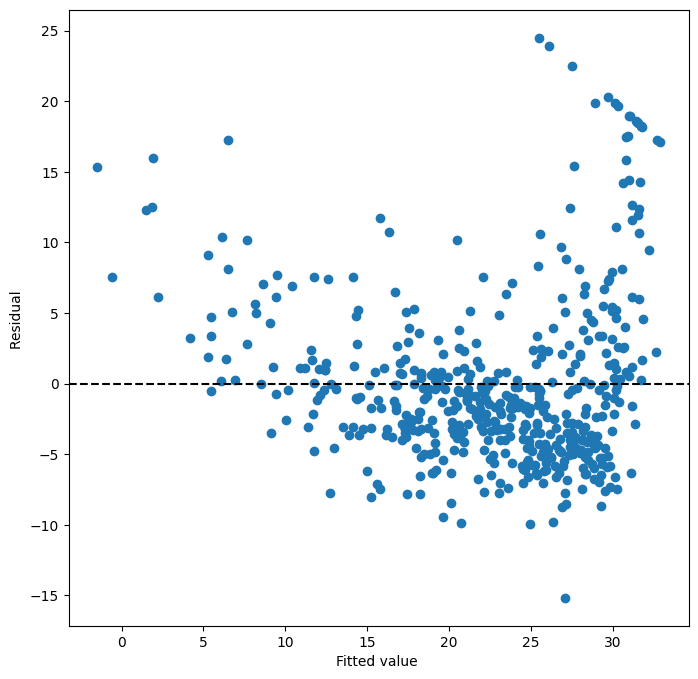

In [24]:
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
ax.axhline (0, c='k', ls='--');

### Leverage plot

We compute influence measures using get_influence() and extract the diagonal elements of the hat matrix (leverage). We plot leverage against observation index. High leverage points may unduly influence the regression. We also find the index of the maximum leverage using np.argmax().

np.int64(374)

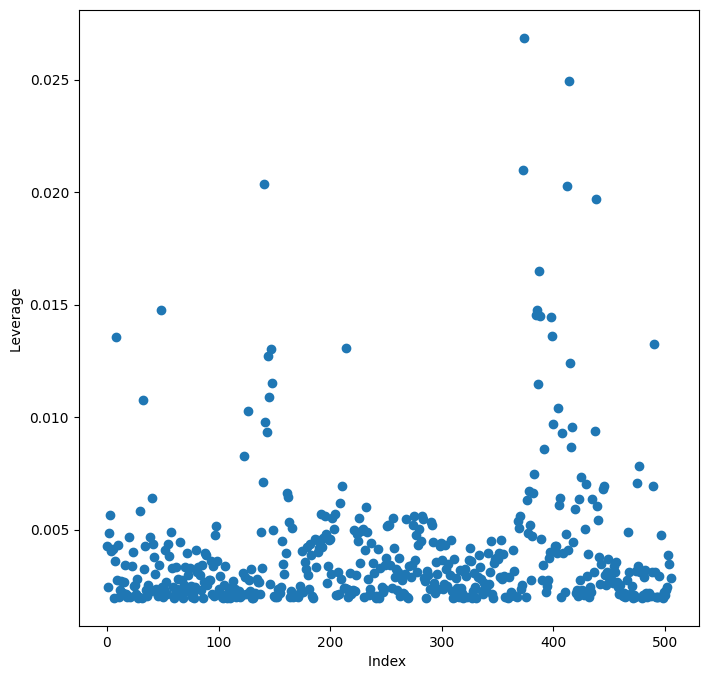

In [25]:
infl = results.get_influence ()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(np.arange(X.shape [0]) , infl.hat_matrix_diag)
ax.set_xlabel('Index ')
ax.set_ylabel('Leverage ')
np.argmax(infl.hat_matrix_diag)

## 3. Multiple linear regression with lstat and age

Now we move to multiple linear regression. We use ModelSpec with two predictors, lstat and age, to build the design matrix. We fit the model using sm.OLS and display the coefficient summary.

In [26]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


### All predictors except medv

To fit a model with all available predictors, we can drop the target variable medv from the column list to get the predictor names. We store these in terms and use them in ModelSpec. This avoids typing all variable names manually.

In [27]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

### Fit full model

We fit the full multiple regression model using all 12 predictors. The summary shows coefficient estimates, standard errors, t‑statistics, and p‑values for each predictor. This helps identify which variables are statistically significant.

In [28]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


### Fit model without age

If we want to exclude a specific predictor (e.g., age which had a high p‑value), we can drop it from the list using columns.drop(). We then fit the reduced model and view its summary. This demonstrates model selection by dropping insignificant variables.

In [29]:
minus_age = Boston.columns.drop (['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


## 4. Multivariate Goodness of Fit [Variance Inflation Factors (VIF)]

We compute Variance Inflation Factors (VIF) to assess multicollinearity among the predictors in the full model. VIF values greater than 5 or 10 indicate problematic collinearity. Here we use a list comprehension to iterate over each column (excluding the intercept) and compute the VIF using variance_inflation_factor(). We then store the results in a DataFrame with the original variable names as indices.

In [30]:
vals = [VIF(X, i)
for i in range (1, X.shape [1])]
vif = pd.DataFrame ({'vif':vals},
index=X.columns [1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


### Alternative loop for VIF

The same VIF calculation can be written using a traditional for loop. This is shown as an alternative to the list comprehension above. Both approaches are equivalent; the list comprehension is more concise and Pythonic.

In [31]:
vals = []
for i in range (1, X.values.shape [1]):
    vals.append(VIF(X.values , i))

## 5. Interaction Terms

We include an interaction term between lstat and age by passing a tuple ('lstat', 'age') to ModelSpec. This adds a product term to the model. We fit the model and display the summary to examine the significance of the interaction coefficient.

In [33]:
X = MS(['lstat','age',('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


## 6. Non-linear Transformations of the Predictors [Polynomial Regression (Quadratic term for lstat)]

We use the poly() function to include a quadratic polynomial of lstat (degree = 2) along with age as predictors. By default, poly() creates orthogonal polynomial columns for numerical stability. The summary shows that the quadratic term is highly significant, indicating a non‑linear relationship between lstat and medv.

In [34]:
X = MS([ poly('lstat', degree =2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


### ANOVA Comparing Linear and Quadratic Models

We perform an analysis of variance (ANOVA) to formally compare the linear model (with lstat and age) against the quadratic model (with the squared term). The anova_lm() function tests whether the additional quadratic term significantly improves the fit. The very small p‑value confirms that the quadratic model is superior.

In [35]:
anova_lm(results1 , results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


### Residual Plot for Quadratic Model

We examine the residuals of the quadratic model against the fitted values. A random scatter around zero indicates that the model assumptions are reasonably met. This plot helps confirm that including the quadratic term has addressed the non‑linearity observed earlier.

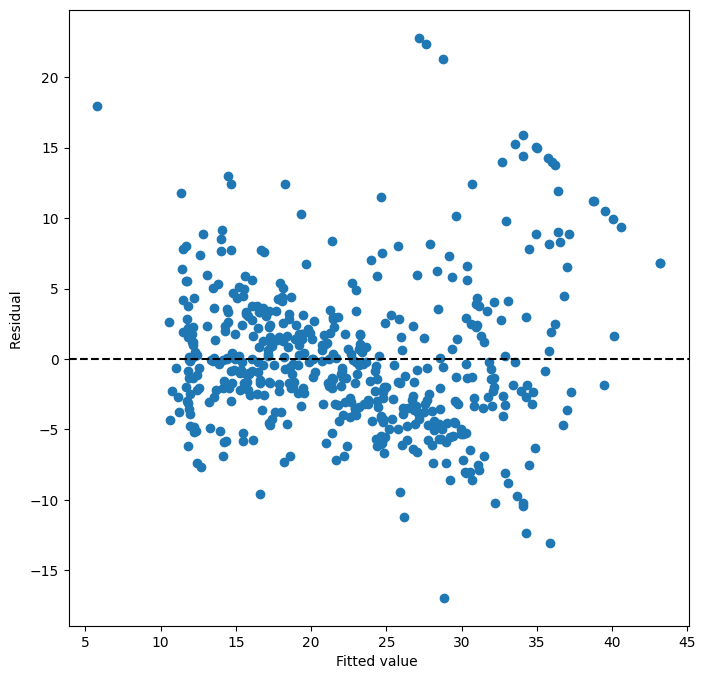

In [36]:
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(results3.fittedvalues , results3.resid)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
ax.axhline (0, c='k', ls='--')

## 7. Qualitative Predictors

### Loading Carseats Data

We load the Carseats data set from the ISLP package, which contains sales of child car seats in 400 locations. This data includes both quantitative and qualitative predictors, such as ShelveLoc (shelf location quality), Urban, and US. We display the column names to see the available variables.

In [37]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

### Model with Qualitative Predictors and Interactions

We build a multiple regression model for Sales using all predictors in the Carseats data. We create a list of variables (allvars) and then add interaction terms: Income:Advertising and Price:Age. The ModelSpec automatically handles categorical variables (e.g., ShelveLoc, Urban, US) by creating dummy variables (one‑hot encoding) and dropping the first level to avoid collinearity with the intercept. The summary shows the effect of each predictor on sales, including the positive impact of a good shelving location.

In [38]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288
